<a href="https://colab.research.google.com/github/Yashika299/Yashika299/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini Project 1   

Yashika Verma

24BCS10511

In [1]:
!pip install opencv-python
!pip install face_recognition
!pip install scikit-learn
!pip install pillow
!pip install pandas
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=1e84b27b9c1ca864c7076f830ba09bb4f609e8ef5397433baf21af71a8bfe751
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [2]:
import os
import cv2
import json
import pickle
import warnings
import numpy as np
import pandas as pd

from PIL import Image

from datetime import datetime

from sklearn.neighbors import KNeighborsClassifier

import face_recognition

In [3]:
PROJECT_NAME = "Face_Attendance_System"

DATASET_PATH = os.path.join(PROJECT_NAME,"student_faces")

MODEL_PATH = os.path.join(PROJECT_NAME,"model")

DATABASE_PATH = os.path.join(PROJECT_NAME,"database")

ATTENDANCE_PATH = os.path.join(PROJECT_NAME,"attendance")

REPORT_PATH = os.path.join(PROJECT_NAME,"reports")

In [4]:
folders = [

    PROJECT_NAME,

    DATASET_PATH,

    MODEL_PATH,

    DATABASE_PATH,

    ATTENDANCE_PATH,

    REPORT_PATH

]

for folder in folders:
    os.makedirs(folder,exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [5]:
CONFIG = {

    "images_per_student":8,

    "knn_neighbors":3,

    "tolerance":0.50,

    "student_file":"students.json",

    "attendance_file":"attendance.csv",

    "model_file":"knn_model.pkl"

}

In [6]:
config_path = os.path.join(PROJECT_NAME,"config.json")

with open(config_path,"w") as f:

    json.dump(CONFIG,f,indent=4)

print("Configuration Saved")

Configuration Saved


In [7]:
student_database = os.path.join(DATABASE_PATH,CONFIG["student_file"])

if not os.path.exists(student_database):

    with open(student_database,"w") as f:

        json.dump([],f)

print("Student Database Ready")

Student Database Ready


In [8]:
attendance_file = os.path.join(ATTENDANCE_PATH,CONFIG["attendance_file"])

if not os.path.exists(attendance_file):

    df = pd.DataFrame(columns=["Student_ID","Name","Date","Time"])

    df.to_csv(attendance_file,index=False)

print("Attendance File Ready")

Attendance File Ready


In [9]:
def generate_student_id():

    with open(student_database,"r") as f:

        students=json.load(f)

    if len(students)==0:

        return "STD001"

    last_id=students[-1]["Student_ID"]

    number=int(last_id.replace("STD",""))

    return f"STD{number+1:03d}"

In [10]:
print(generate_student_id())

STD001


In [11]:
def register_student():

    name=input("Student Name : ")

    roll=input("Roll Number : ")

    email=input("Email : ")

    department=input("Department : ")

    sid=generate_student_id()

    student={

        "Student_ID":sid,

        "Name":name,

        "Roll":roll,

        "Email":email,

        "Department":department

    }

    with open(student_database,"r") as f:

        data=json.load(f)

    data.append(student)

    with open(student_database,"w") as f:

        json.dump(data,f,indent=4)

    print()

    print("Student Registered Successfully")

    print("Student ID :",sid)

In [12]:
register_student()

Student Name : Rahul
Roll Number : 123
Email : abc@gmail.com
Department : CSE

Student Registered Successfully
Student ID : STD001


In [13]:
with open(student_database,"r") as f:

    students=json.load(f)

pd.DataFrame(students)

,Student_ID,Name,Roll,Email,Department
0,STD001,Rahul,123,abc@gmail.com,CSE


In [14]:
from google.colab import files
import shutil

def upload_student_images():

    student_id = input("Enter Student ID (e.g., STD001): ")

    student_folder = os.path.join(DATASET_PATH, student_id)

    os.makedirs(student_folder, exist_ok=True)

    print("\nUpload 5-10 clear face images of the student.")

    uploaded = files.upload()

    count = 0

    for filename in uploaded.keys():

        destination = os.path.join(student_folder, filename)

        shutil.move(filename, destination)

        count += 1

    print(f"\n{count} images uploaded successfully.")

In [15]:
upload_student_images()

Enter Student ID (e.g., STD001): STD001

Upload 5-10 clear face images of the student.


Saving rahul5.jfif to rahul5.jfif
Saving rahul4.jfif to rahul4.jfif
Saving rahul3.jpg to rahul3.jpg
Saving rahul2.jfif to rahul2.jfif
Saving rahul1.jpg to rahul1.jpg

5 images uploaded successfully.


In [16]:
student_id = "STD001"

folder = os.path.join(DATASET_PATH, student_id)

print("Images Found:")
print(os.listdir(folder))

Images Found:
['rahul1.jpg', 'rahul4.jfif', 'rahul5.jfif', 'rahul2.jfif', 'rahul3.jpg']


In [17]:
encodings = []
labels = []

with open(student_database, "r") as f:
    students = json.load(f)

for student in students:

    sid = student["Student_ID"]
    folder = os.path.join(DATASET_PATH, sid)

    if not os.path.exists(folder):
        continue

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        image = face_recognition.load_image_file(image_path)

        face_locations = face_recognition.face_locations(image)

        if len(face_locations) == 0:
            print(f"No face found in {image_name}")
            continue

        encoding = face_recognition.face_encodings(image, face_locations)[0]

        encodings.append(encoding)
        labels.append(sid)

print("\nEncoding Completed")
print("Total Face Samples:", len(encodings))


Encoding Completed
Total Face Samples: 5


In [18]:
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

knn_model.fit(encodings, labels)

print("✅ Face Recognition Model Trained Successfully")

✅ Face Recognition Model Trained Successfully


In [19]:
model_path = os.path.join(MODEL_PATH, CONFIG["model_file"])

with open(model_path, "wb") as file:
    pickle.dump(knn_model, file)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [20]:
with open(model_path, "rb") as file:
    model = pickle.load(file)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [21]:
from google.colab import files

print("Upload a test image")

uploaded = files.upload()

for filename in uploaded.keys():

    image = face_recognition.load_image_file(filename)

    locations = face_recognition.face_locations(image)

    if len(locations) == 0:
        print("❌ No face detected.")
        continue

    encoding = face_recognition.face_encodings(image, locations)[0]

    prediction = model.predict([encoding])[0]

    print("✅ Predicted Student ID:", prediction)

Upload a test image


Saving rahul1.jpg to rahul1.jpg
✅ Predicted Student ID: STD001


In [22]:
with open(student_database, "r") as f:
    students = json.load(f)

student_dict = {}

for student in students:
    student_dict[student["Student_ID"]] = student["Name"]

print(student_dict)

{'STD001': 'Rahul'}


In [23]:
def mark_attendance(student_id):

    name = student_dict[student_id]

    today = datetime.now().strftime("%d-%m-%Y")
    current_time = datetime.now().strftime("%H:%M:%S")

    attendance = pd.read_csv(attendance_file)

    # Prevent duplicate attendance on the same day
    already_marked = (
        (attendance["Student_ID"] == student_id) &
        (attendance["Date"] == today)
    ).any()

    if already_marked:
        print(f"⚠ Attendance already marked for {name} today.")
        return

    new_record = pd.DataFrame({
        "Student_ID": [student_id],
        "Name": [name],
        "Date": [today],
        "Time": [current_time]
    })

    attendance = pd.concat([attendance, new_record], ignore_index=True)

    attendance.to_csv(attendance_file, index=False)

    print(f"✅ Attendance Marked Successfully for {name}")

In [24]:
print("Upload an image to mark attendance")

uploaded = files.upload()

for filename in uploaded.keys():

    image = face_recognition.load_image_file(filename)

    locations = face_recognition.face_locations(image)

    if len(locations) == 0:
        print("❌ No face detected.")
        continue

    encoding = face_recognition.face_encodings(image, locations)[0]

    prediction = model.predict([encoding])[0]

    print("Recognized Student:", prediction)

    mark_attendance(prediction)

Upload an image to mark attendance


Saving rahul3.jpg to rahul3.jpg
Recognized Student: STD001
✅ Attendance Marked Successfully for Rahul


In [25]:
attendance = pd.read_csv(attendance_file)

attendance

,Student_ID,Name,Date,Time
0,STD001,Rahul,27-06-2026,03:29:51


In [26]:
attendance = pd.read_csv(attendance_file)

print("Total Attendance Records :", len(attendance))

print("\nAttendance Summary")

attendance.groupby("Name").size()

Total Attendance Records : 1

Attendance Summary


,0
Name,
Rahul,1


In [27]:
attendance = pd.read_csv(attendance_file)

print("Total Attendance Records :", len(attendance))

print("\nAttendance Summary")

attendance.groupby("Name").size()

Total Attendance Records : 1

Attendance Summary


,0
Name,
Rahul,1


In [29]:
with open(student_database, "r") as f:
    students = json.load(f)

print("=" * 40)
print("        STUDENT DASHBOARD")
print("=" * 40)

print(f"Total Registered Students : {len(students)}")

        STUDENT DASHBOARD
Total Registered Students : 1


In [30]:
attendance = pd.read_csv(attendance_file)

today = datetime.now().strftime("%d-%m-%Y")

today_attendance = attendance[attendance["Date"] == today]

print(f"Today's Attendance : {len(today_attendance)}")

Today's Attendance : 1


In [31]:
attendance = pd.read_csv(attendance_file)

attendance

,Student_ID,Name,Date,Time
0,STD001,Rahul,27-06-2026,03:29:51


In [32]:
attendance = pd.read_csv(attendance_file)

attendance_summary = attendance.groupby("Name").size().reset_index(name="Total Attendance")

attendance_summary

,Name,Total Attendance
0,Rahul,1


In [34]:
!pip install matplotlib
import matplotlib.pyplot as plt

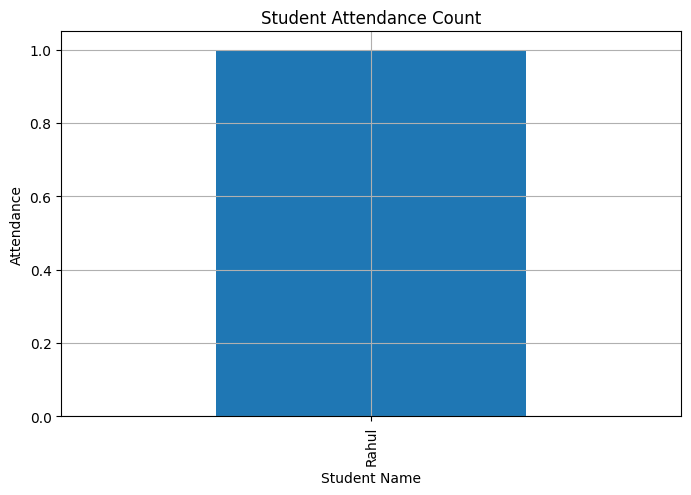

In [35]:
attendance_summary.plot(
    x="Name",
    y="Total Attendance",
    kind="bar",
    figsize=(8,5),
    legend=False,
    title="Student Attendance Count"
)

plt.xlabel("Student Name")
plt.ylabel("Attendance")
plt.grid(True)

plt.show()

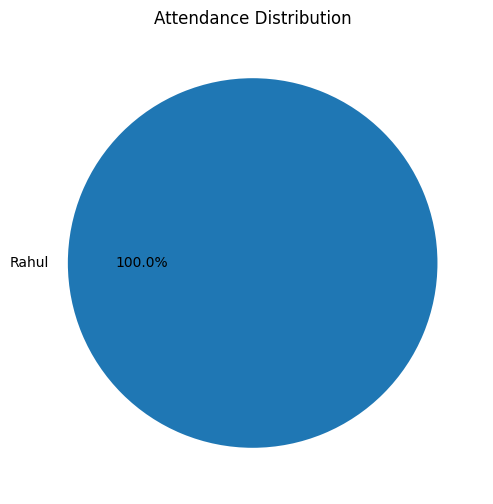

In [36]:
attendance_summary.set_index("Name")["Total Attendance"].plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Attendance Distribution"
)

plt.ylabel("")
plt.show()

In [37]:
search_name = input("Enter Student Name : ")

result = attendance[attendance["Name"].str.lower() == search_name.lower()]

if len(result) == 0:
    print("Student Not Found")
else:
    display(result)

Enter Student Name : rahul


,Student_ID,Name,Date,Time
0,STD001,Rahul,27-06-2026,03:29:51


In [38]:
from google.colab import files

files.download(attendance_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
summary = attendance.groupby("Name").size().reset_index(name="Total Attendance")

summary.to_csv("attendance_summary.csv", index=False)

print("Attendance Summary Saved")

Attendance Summary Saved


In [41]:
files.download("attendance_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
with open(student_database, "r") as f:
    students = json.load(f)

pd.DataFrame(students)

,Student_ID,Name,Roll,Email,Department
0,STD001,Rahul,123,abc@gmail.com,CSE


In [43]:
print("="*50)
print(" AI BASED FACE RECOGNITION ATTENDANCE SYSTEM ")
print("="*50)

print(f"Registered Students : {len(students)}")

attendance = pd.read_csv(attendance_file)

print(f"Attendance Records : {len(attendance)}")

print(f"Model Used : KNN")

print(f"Images Per Student : {CONFIG['images_per_student']}")

print("="*50)

 AI BASED FACE RECOGNITION ATTENDANCE SYSTEM 
Registered Students : 1
Attendance Records : 1
Model Used : KNN
Images Per Student : 8
